In [111]:
import random
import itertools
import copy
import numpy as np
import matplotlib.pyplot as plt

In [112]:
random.seed(67)

translation = {2:"2", 3:"3", 4:"4", 5:"5", 6:"6", 7:"7", 8:"8", 9:"9", 10:"10", 11:"J", 12:"Q", 13:"K", 14:"A"}
translation_s = {"C":1, "D":2, "H":3, "S":4}
translation_hand = {"high":1, "pair":2, "dual pair":3, "triple":4, "straight":5, "flush":6, "full house":7, "quad":8, "straight flush":9}
vals = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12", "13", "14"]
suits = ["D", "H", "C", "S"]

front_size = 3
mid_back_size = 5

class card:
    def __init__(self, value, suit):
        #Numerical equivalent *14:Ace
        self.value = value

        #One letter suit (D:Diamonds)
        self.suit = suit

    def __str__(self):
        #Returns the card as a string
        return (f"{translation[self.value]}{self.suit}")

    def __lt__(self, other):
        if self.value != other.value:
            return self.value < other.value
        else:
            return translation_s[self.suit] < translation_s[other.suit]

    def __gt__(self, other):
        if self.value != other.value:
            return self.value > other.value
        else:
            return translation_s[self.suit] > translation_s[other.suit]

    def __eq__(self, other):
        return self.value == other.value and self.suit == other.suit

    def get_value(self):
        return self.value

    def get_suit(self):
        return self.suit

def createChineseHand():
    hand_str = []
    hand_card = []
    for i in range(13):
        num = random.choice(vals)
        suit = random.choice(suits)
        combined = f"{num}{suit}"
        while combined in hand_str:
            num = random.choice(vals)
            suit = random.choice(suits)
            combined = f"{num}{suit}"
        hand_str.append(combined)
    for c in hand_str:
        hand_card.append(card(int(c[:-1]),c[-1]))
    for c in hand_card:
        print(str(c))
    return hand_card

def create2Hands():
    #Draws two chinese poker hands for two players
    hand_1 = []
    hand_2 = []
    hand_card_1 = []
    hand_card_2 = []
    for i in range(13):
        num = random.choice(vals)
        suit = random.choice(suits)
        combined = f"{num}{suit}"
        while combined in hand_1 or combined in hand_2:
            num = random.choice(vals)
            suit = random.choice(suits)
            combined = f"{num}{suit}"
        hand_1.append(combined)
    for i in range(13):
        num = random.choice(vals)
        suit = random.choice(suits)
        combined = f"{num}{suit}"
        while combined in hand_1 or combined in hand_2:
            num = random.choice(vals)
            suit = random.choice(suits)
            combined = f"{num}{suit}"
        hand_2.append(combined)
    
    s = ""
    for c in sorted(hand_1):
        hand_card_1.append(card(int(c[:-1]),c[-1]))
        s += f"{c} "
    #print("player 1:", s)
    s = ""
    for c in sorted(hand_2):
        hand_card_2.append(card(int(c[:-1]),c[-1]))
        s += f"{c} "
    #print("player 2:", s)
    return hand_card_1, hand_card_2

In [113]:
random.seed(67)
def printSolutions(A):
    for i in range(len(A)):
        p = f"hand {i}: "
        for x in A[i]:
            p += f" {str(x)} "
        print(p)

In [152]:
random.seed(67)
def scoreHand(hand, handtype):
    scores = [0, 0, 0, 0, 0]
    if handtype == "high":
        for i in range(0, 5):
            if i < len(hand):
                scores[i] = hand[i].get_value()
    elif handtype == "pair":
        scores[0] = 13 + hand[0].get_value()
        for i in range(1, 4):
            if (i+1) < len(hand):
                scores[i] = hand[i+1].get_value()
    elif handtype == "dual pair":
        scores[0] = 23 + hand[2].get_value()
        scores[1] = hand[0].get_value()
        scores[2] = hand[4].get_value()
    elif handtype == "triple":
        scores[0] = 49 + hand[0].get_value()
        for i in range(1, 3):
            if (i+2) < len(hand):
                scores[i] = hand[i+2].get_value()
    elif handtype == "straight":
        if hand[0].get_value() == 2 and hand[4].get_value() == 14:
            scores[0] = 64
        else:
            scores[0] = 59 + hand[4].get_value()
    elif handtype == "flush":
        scores[0] = 68 + hand[4].get_value()
        for i in range(1, 5):
            scores[i] = hand[4-i].get_value()
    elif handtype == "full house":
        scores[0] = 87 + hand[2].get_value()
        scores[1] = hand[0].get_value()
    elif handtype == "quad":
        scores[0] = 100 + hand[0].get_value()
        scores[1] = hand[4].get_value()
    elif handtype == "straight flush":
        if hand[0].get_value() == 2 and hand[4].get_value() == 14:
            scores[0] = 115
        else:
            scores[0] = 110 + hand[4].get_value()

    return scores

def compareHands(hand1, hand1_t, hand2, hand2_t):
    num_1_t = translation_hand[hand1_t]
    num_2_t = translation_hand[hand2_t]
    if num_1_t > num_2_t:
        return 1, 0
    elif num_1_t < num_2_t:
        return 0, 1
    else:
        scores_1 = scoreHand(hand1, hand1_t)
        scores_2 = scoreHand(hand2, hand2_t)
        for i in range(len(scores_1)):
            if scores_1[i] > scores_2[i]:
                return 1, 0
            elif scores_1[i] < scores_2[i]:
                return 0, 1
            elif scores_1[i] == scores_2[i] and (num_1_t in [5, 9]):
                suit1 = translation_s[hand1[0].get_suit()]
                suit2 = translation_s[hand2[0].get_suit()]
                if suit1 > suit2:
                    return 1, 0
                elif suit1 < suit2:
                    return 0, 1
            else:
                continue

        if num_1_t == 1:
            suit1 = translation_s[hand1[0].get_suit()]
            suit2 = translation_s[hand2[0].get_suit()]
            if suit1 > suit2:
                return 1, 0
            elif suit1 < suit2:
                return 0, 1

        elif num_1_t == 2:
            suit1 = translation_s[hand1[1].get_suit()]
            suit2 = translation_s[hand2[1].get_suit()]
            if suit1 > suit2:
                return 1, 0
            elif suit1 < suit2:
                return 0, 1

        elif num_1_t == 3:
            suit1 = translation_s[hand1[3].get_suit()]
            suit2 = translation_s[hand2[3].get_suit()]
            if suit1 > suit2:
                return 1, 0
            elif suit1 < suit2:
                return 0, 1

        elif num_1_t == 6:
            suit1 = translation_s[hand1[0].get_suit()]
            suit2 = translation_s[hand2[0].get_suit()]
            if suit1 > suit2:
                return 1, 0
            elif suit1 < suit2:
                return 0, 1
            
    #Player 2 wins
    #return 0, 1
    #Player 1 wins
    #return 1, 0

def compareFullHands(fh_1, fh_1_t, fh_2, fh_2_t):
    score1 = 0
    score2 = 0
    for i in range(3):
        s1, s2 = compareHands(fh_1[i], fh_1_t[i], fh_2[i], fh_2_t[i])
        score1 += s1
        score2 += s2

    return score1, score2

def compareFullHands16(fh_1, fh_1_t, fh_2, fh_2_t):
    score1 = 0
    score2 = 0
    for i in range(3):
        s1, s2 = compareHands(fh_1[i], fh_1_t[i], fh_2[i], fh_2_t[i])
        score1 += s1
        score2 += s2

    if score1 == 3:
        score1 = 6
    elif score2 == 3:
        score2 = 6

    return score1, score2

In [153]:
random.seed(67)
def find_hands(chineseHand):
    nums = sorted(chineseHand)
    current = 1
    count = 1
    p = []
    t = []
    q = []
    dp = []
    fh = []
    match_lengths = []
    current_stack = [nums[0]]
    for ci in range(len(nums)):
        card = nums[ci]
        if current == card.get_value():
            current_stack.append(card)
            count += 1
        else:
            if count > 1:
                if count == 2:
                    p.append(current_stack)
                elif count == 3:
                    t.append(current_stack)
                    tp = [list(h) for h in tuple(itertools.combinations(current_stack, 2))]
                    p += tp
                else:
                    q.append(current_stack)
                    qt = [list(h) for h in tuple(itertools.combinations(current_stack, 3))]
                    qp = [list(h) for h in tuple(itertools.combinations(current_stack, 2))]
                    t += qt
                    p += qp
                current_stack = [card]
                count = 1
            current_stack = [card]
            current = card.get_value()

        if ci == len(nums)-1 and count > 1:
            if count == 2:
                p.append(current_stack)
            elif count == 3:
                t.append(current_stack)
                tp = [list(h) for h in tuple(itertools.combinations(current_stack, 2))]
                p += tp
            else:
                q.append(current_stack)
                qt = [list(h) for h in tuple(itertools.combinations(current_stack, 3))]
                qp = [list(h) for h in tuple(itertools.combinations(current_stack, 2))]
                t += qt
                p += qp

    dp_combs = []
    fh_combs = []
    if p:
        dp_combs = itertools.combinations(p, 2)
    
    if t:
        fh_combs = itertools.product(p, t)

    for hand in dp_combs:
        disjoint = False
        for cd in hand[0]:
            if cd in hand[1] or hand[1][0].get_value() == cd.get_value():
                disjoint = True
                break
        
        if not disjoint:
            dp.append(hand[0] + hand[1])

    for hand in fh_combs:
        disjoint = False
        for cd in hand[0]:
            if cd in hand[1]:
                disjoint = True
                break
        
        if not disjoint:
            fh.append(hand[0] + hand[1])

    f = []
    s = []
    sf = []
    combinations = list(itertools.combinations(nums, 5))
    for hand in combinations:
        hand = list(hand)
        start = hand[0].get_value()
        suit = hand[0].get_suit()

        straight = True
        flush = True

        for i in range(1, 5):
            start += 1
            if hand[i].get_value() != start:
                straight = False
                break

        for i in range(1, 5):
            if hand[i].get_suit() != suit:
                flush = False
                break
        
        h = hand
        if (hand[0].get_value()==2 and 
            hand[1].get_value()==3 and 
            hand[2].get_value()==4 and 
            hand[3].get_value()==5 and 
            hand[4].get_value()==14):
            straight = True
            h = [hand[4], hand[0], hand[1], hand[2], hand[3]]

        if straight and flush:
            sf.append(h)
        elif straight:
            s.append(h)
        elif flush:
            f.append(h)

    
    dp = sorted(dp, key=lambda x: (x[2].get_value(), x[0].get_value()))
    fh = sorted(fh, key=lambda x: (x[2].get_value(), x[2].get_value() - x[0].get_value()))
       
    final = [[], []] + p + dp + t + s + f + fh + q + sf
    final_types = (["high", "high"] + ["pair" for i in range(len(p))]
                   + ["dual pair" for i in range(len(dp))]
                   + ["triple" for i in range(len(t))]
                   + ["straight" for i in range(len(s))]
                   + ["flush" for i in range(len(f))]
                   + ["full house" for i in range(len(fh))]
                   + ["quad" for i in range(len(q))]
                   + ["straight flush" for i in range(len(sf))])
    return final, final_types

In [154]:
random.seed(67)
def suit_in_hand(suit, hand):
    for card in hand:
        if card.get_suit() == suit:
            return True
    return False

def print_hand(hand):
    s = ""
    for card in hand:
        s += str(card) + " "

    return s

def eliminate_hands(A, T, hand):
    #Remove hands in A with cards from hand
    #Repeat changes in T
    s = copy.deepcopy(A)
    t = copy.deepcopy(T)
    for j in range(len(A)-1, -1, -1):
        for i in hand:
            if i in A[j]:
                s.pop(j)
                t.pop(j)
                break
    if hand == []:
        return s, t
    if s == []:
        return False
    return s, t

def get_remaining(Chinese, Hand):
    rem = [Card for Card in Chinese if Card not in Hand]
    return sorted(rem)

def check_remaining(remaining):
    nums = sorted(remaining)
    current = 1
    count = 0
    match_lengths = []
    if remaining:
        current_stack = [nums[0]]
        for ci in range(len(nums)):
            card = nums[ci]
            if current == card.get_value():
                current_stack.append(card)
                count += 1
            else:
                if count > 1:
                    return False
                count = 1
                current_stack = [card]
                current = card.get_value()
    
            if ci == len(nums)-1 and count > 1:
                return False
    
    return True

def fill_highs(remaining, front, mid, back, types):
    #Fills hand with remaining cards
    r = remaining
    middle = copy.deepcopy(mid)
    if check_remaining(r):
        if (types[1] == types[0] and types[0] == "high"):
            c = r.pop()
            n = c.get_value()
            for i in middle:
                if i.get_value() == n:
                    return False
            middle.append(c)

            fc = r.pop()
            fn = c.get_value()
            for i in front:
                if i.get_value() == fn:
                    return False
            front.append(fc)

            if fn == n:
                c = r.pop()
                n = c.get_value()
                for i in middle:
                    if i.get_value() == n:
                        return False
                middle.append(c)
            
        while len(front) < 3:
            c = r.pop()
            n = c.get_value()
            for i in front:
                if i.get_value() == n:
                    return False
            front.append(c)
            
        while len(middle) < 5:
            c = r.pop()
            n = c.get_value()
            for i in middle:
                if i.get_value() == n:
                    return False
            middle.append(c)
    
        while len(back) < 5:
            c = r.pop()
            n = c.get_value()
            for i in back:
                if i.get_value() == n:
                    return False
            back.append(c)

        return [front, middle, back]

    else:
        if (types[1] == types[0] and types[0] == "high"):
            c = r.pop()
            n = c.get_value()
            for i in middle:
                if i.get_value() == n:
                    return False
            middle.append(c)

            fc = r.pop()
            fn = c.get_value()
            for i in front:
                if i.get_value() == fn:
                    return False
            front.append(fc)

            if fn == n:
                c = r.pop()
                n = c.get_value()
                for i in middle:
                    if i.get_value() == n:
                        return False
                middle.append(c)

        if (types[1] == types[0] and types[0] == "pair"):
            c = r.pop()
            n = c.get_value()
            for i in middle:
                if i.get_value() == n:
                    return False
            middle.append(c)

        c = "044"
        while len(front) < 3:
            p = c
            c = r.pop()
            if str(p)[:-1] == str(c)[:-1]:
                return False
            n = c.get_value()
            for i in front:
                if i.get_value() == n:
                    return False
            front.append(c)

        c = "044"
        while len(middle) < 5:
            p = c
            c = r.pop()
            if str(p)[:-1] == str(c)[:-1]:
                return False
            n = c.get_value()
            for i in middle:
                if i.get_value() == n:
                    return False
            middle.append(c)

        c = "044"
        while len(back) < 5:
            p = c
            c = r.pop()
            if str(p)[:-1] == str(c)[:-1]:
                return False       
            n = c.get_value()
            for i in back:
                if i.get_value() == n:
                    return False
            back.append(c)

        #print("back filled")
        return [front, middle, back]

def print_arrangement(i):
    f = f"{str(i[0][0])} {str(i[0][1])} {str(i[0][2])}"
    m = f"{str(i[1][0])} {str(i[1][1])} {str(i[1][2])} {str(i[1][3])} {str(i[1][4])}"
    b = f"{str(i[2][0])} {str(i[2][1])} {str(i[2][2])} {str(i[2][3])} {str(i[2][4])}"
    t = "hand:"
    print(t)
    print(f)
    print(m)
    print(b)

In [155]:
random.seed(67)
def findBestHands(p1_H, p1_T, p2_H, p2_T, strategy1, strategy2, suppress=False):
    #Find generally best hands
    hand_scores_1 = []
    hand_scores_2 = []
    for i in range(len(p1_H)):
        hand_scores_1.append(0)
    for i in range(len(p2_H)):
        hand_scores_2.append(0)
    
    for k in range(len(p1_H)):
        score = 0
        for l in range(len(p2_H)):
            p1, p2 = compareFullHands(p1_H[k], p1_T[k], p2_H[l], p2_T[l])
            score += p1
            hand_scores_2[l] += p2
        hand_scores_1[k] = score

    best_hand_1 = hand_scores_1.index(max(hand_scores_1))
    best_hand_2 = hand_scores_2.index(max(hand_scores_2))        
    #Find hands to counter best hands
    hand_scores_1 = []
    for i in range(len(p1_H)):
        hand_scores_1.append(0)

    for i in range(len(p1_H)):
        p1, p2 = compareFullHands(p1_H[i], p1_T[i], p2_H[best_hand_2], p2_T[best_hand_2])
        hand_scores_1[i] += p1

    counter_hand_1 = hand_scores_1.index(max(hand_scores_1))
    
    hand_scores_2 = []
    for i in range(len(p2_H)):
        hand_scores_2.append(0)
    
    for i in range(len(p2_H)):
        p1, p2 = compareFullHands(p1_H[best_hand_1], p1_T[best_hand_1], p2_H[i], p2_T[i])
        hand_scores_2[i] += p2
        
    counter_hand_2 = hand_scores_2.index(max(hand_scores_2))

    #Find hand to counter counters
    hand_scores_1 = []
    for i in range(len(p1_H)):
        hand_scores_1.append(0)

    for i in range(len(p1_H)):
        p1, p2 = compareFullHands(p1_H[i], p1_T[i], p2_H[counter_hand_2], p2_T[counter_hand_2])
        hand_scores_1[i] += p1

    counter2_hand_1 = hand_scores_1.index(max(hand_scores_1))
    
    hand_scores_2 = []
    for i in range(len(p2_H)):
        hand_scores_2.append(0)
    
    for i in range(len(p2_H)):
        p1, p2 = compareFullHands(p1_H[counter_hand_1], p1_T[counter_hand_1], p2_H[i], p2_T[i])
        hand_scores_2[i] += p2

    counter2_hand_2 = hand_scores_2.index(max(hand_scores_2))

    if not suppress:
        for q in [best_hand_1, counter_hand_1, counter2_hand_1]:
            print_arrangement(p1_H[q])
    
        for q in [best_hand_2, counter_hand_2, counter2_hand_2]:
            print_arrangement(p2_H[q])

    if strategy1 == "best":
        rh1 = p1_H[best_hand_1]
        rt1 = p1_T[best_hand_1]

    elif strategy1 == "counter":
        rh1 = p1_H[counter_hand_1]
        rt1 = p1_T[counter_hand_1]

    elif strategy1 == "counter2":
        rh1 = p1_H[counter2_hand_1]
        rt1 = p1_T[counter2_hand_1]

    elif strategy1 == "bmf":
        rh1 = p1_H[-1]
        rt1 = p1_T[-1]

    elif strategy1 == "rand":
        rc = random.randint(0, len(p1_H)-1)
        rh1 = p1_H[rc]
        rt1 = p1_T[rc]

    if strategy2 == "best":
        rh2 = p2_H[best_hand_2]
        rt2 = p2_T[best_hand_2]

    elif strategy2 == "counter":
        rh2 = p2_H[counter_hand_2]
        rt2 = p2_T[counter_hand_2]

    elif strategy2 == "counter2":
        rh2 = p2_H[counter2_hand_2]
        rt2 = p2_T[counter2_hand_2]

    elif strategy2 == "counter3":
        rh2 = p2_H[counter3_hand_2]
        rt2 = p2_T[counter3_hand_2]

    elif strategy2 == "bmf":
        rh2 = p2_H[-1]
        rt2 = p2_T[-1]

    elif strategy1 == "rand":
        rc = random.randint(0, len(p2_H)-1)
        rh2 = p2_H[rc]
        rt2 = p2_T[rc]
    
    return rh1, rt1, rh2, rt2

In [156]:
random.seed(67)
def findBest16(p1_H, p1_T, p2_H, p2_T, strategy1, strategy2, suppress=False, threshold=0.5):
    #Find generally best hands
    hand_scores_1 = []
    hand_scores_2 = []
    for i in range(len(p1_H)):
        hand_scores_1.append(0)
    for i in range(len(p2_H)):
        hand_scores_2.append(0)
    
    for i in range(len(p1_H)):
        score = 0
        for j in range(len(p2_H)):
            p1, p2 = compareFullHands(p1_H[i], p1_T[i], p2_H[j], p2_T[j])
            score += p1
            hand_scores_2[j] += p2
        hand_scores_1[i] = score

    best_hand_1 = hand_scores_1.index(max(hand_scores_1))
    best_hand_2 = hand_scores_2.index(max(hand_scores_2))        
    #Find hands to counter best hands
    hand_scores_1 = []
    for i in range(len(p1_H)):
        hand_scores_1.append(0)

    for i in range(len(p1_H)):
        p1, p2 = compareFullHands(p1_H[i], p1_T[i], p2_H[best_hand_2], p2_T[best_hand_2])
        hand_scores_1[i] += p1

    counter_hand_1 = hand_scores_1.index(max(hand_scores_1))
    
    hand_scores_2 = []
    for i in range(len(p2_H)):
        hand_scores_2.append(0)
    
    for i in range(len(p2_H)):
        p1, p2 = compareFullHands(p1_H[best_hand_1], p1_T[best_hand_1], p2_H[i], p2_T[i])
        hand_scores_2[i] += p2
        
    counter_hand_2 = hand_scores_2.index(max(hand_scores_2))

    #Find hand to counter counters
    hand_scores_1 = []
    for i in range(len(p1_H)):
        hand_scores_1.append(0)

    for i in range(len(p1_H)):
        p1, p2 = compareFullHands(p1_H[i], p1_T[i], p2_H[counter_hand_2], p2_T[counter_hand_2])
        hand_scores_1[i] += p1

    counter2_hand_1 = hand_scores_1.index(max(hand_scores_1))
    
    hand_scores_2 = []
    for i in range(len(p2_H)):
        hand_scores_2.append(0)
    
    for i in range(len(p2_H)):
        p1, p2 = compareFullHands(p1_H[counter_hand_1], p1_T[counter_hand_1], p2_H[i], p2_T[i])
        hand_scores_2[i] += p2

    counter2_hand_2 = hand_scores_2.index(max(hand_scores_2))

    if not suppress:
        for q in [best_hand_1, counter_hand_1, counter2_hand_1]:
            print_arrangement(p1_H[q])
    
        for q in [best_hand_2, counter_hand_2, counter2_hand_2]:
            print_arrangement(p2_H[q])

    if strategy1 == "best":
        scores = []
        rh1 = p1_H[best_hand_1]
        rt1 = p1_T[best_hand_1]
        for i in [best_hand_2, counter_hand_2, counter2_hand_2]:
            rh2 = p2_H[i]
            rt2 = p2_T[i]
            p1, p2 = compareFullHands(rh1, rt1, rh2, rt2)
            scores.append(p1)
            
        if scores.count(0)/len(scores) > threshold:
            rh1 = "surrender"
        
    elif strategy1 == "counter":
        scores = []
        rh1 = p1_H[counter_hand_1]
        rt1 = p1_T[counter_hand_1]
        for i in [best_hand_2, counter_hand_2, counter2_hand_2]:
            rh2 = p2_H[i]
            rt2 = p2_T[i]
            p1, p2 = compareFullHands(rh1, rt1, rh2, rt2)
            scores.append(p1)
            
        if scores.count(0)/len(scores) > threshold:
            rh1 = "surrender"

    elif strategy1 == "counter2":
        scores = []
        rh1 = p1_H[counter2_hand_1]
        rt1 = p1_T[counter2_hand_1]
        for i in [best_hand_2, counter_hand_2, counter2_hand_2]:
            rh2 = p2_H[i]
            rt2 = p2_T[i]
            p1, p2 = compareFullHands(rh1, rt1, rh2, rt2)
            scores.append(p1)
            
        if scores.count(0)/len(scores) > threshold:
            rh1 = "surrender"

    if strategy2 == "best":
        scores = []
        rh2 = p2_H[best_hand_2]
        rt2 = p2_T[best_hand_2]
        for i in [best_hand_1, counter_hand_1, counter2_hand_1]:
            rh1 = p1_H[i]
            rt1 = p1_T[i]
            p1, p2 = compareFullHands(rh1, rt1, rh2, rt2)
            scores.append(p2)
            
        if scores.count(0)/len(scores) > threshold:
            rh2 = "surrender"

    elif strategy2 == "counter":
        scores = []
        rh2 = p2_H[counter_hand_2]
        rt2 = p2_T[counter_hand_2]
        for i in [best_hand_1, counter_hand_1, counter2_hand_1]:
            rh1 = p1_H[i]
            rt1 = p1_T[i]
            p1, p2 = compareFullHands(rh1, rt1, rh2, rt2)
            scores.append(p2)
            
        if scores.count(0)/len(scores) > threshold:
            rh2 = "surrender"

    elif strategy2 == "counter2":
        scores = []
        rh2 = p2_H[counter2_hand_2]
        rt2 = p2_T[counter2_hand_2]
        for i in [best_hand_1, counter_hand_1, counter2_hand_1]:
            rh1 = p1_H[i]
            rt1 = p1_T[i]
            p1, p2 = compareFullHands(rh1, rt1, rh2, rt2)
            scores.append(p2)
            
        if scores.count(0)/len(scores) > threshold:
            rh2 = "surrender"
    
    return rh1, rt1, rh2, rt2

In [161]:
random.seed(67)
def MFB(Chinese, Hands, HandTypes, suppress=False):
    aSols = []
    aSolTypes = []
    breakfor = False
    # Creates a Chinese Poker Hand given the middle front back approach
    for i in range(len(Hands)-2, 0, -1):
        front = eliminate_hands(Hands[0:i+1], HandTypes[0:i+1], Hands[i])
        back = eliminate_hands(Hands[i:len(Hands)], HandTypes[i:len(Hands)], Hands[i])
        if not back:
            #Mid Sacrifices Back, Skip due to Rules
            continue
        if back and front:
            #print(f"at {i}, back {len(back)}, front {len(front)}")
            #If Mid Allows for Back and Front, Optimize Front then Back
            fh, ft = front
            bh1, bt1 = back
            for j in range(len(fh)-1, -1, -1):
                if len(fh[j]) <= 3:
                    back = eliminate_hands(bh1, bt1, fh[j])
                    if not back:
                        #Front Sacrifices Back, Skip due to Rules
                        continue
                    else:
                        r = Chinese
                        r = get_remaining(Chinese, Hands[i])
                        bh, bt = back
                        r = get_remaining(r, fh[j])
                        r = get_remaining(r, bh[-1])
                        full = fill_highs(r, fh[j], Hands[i], bh[-1], [ft[j], HandTypes[i], bt[-1]])
                        if full:
                            aSols.append(full)
                            aSolTypes.append([ft[j], HandTypes[i], bt[-1]])
    aSols = aSols[0::2]
    aSolTypes = aSolTypes[0::2]
    if not suppress:
        for i in aSols:
            print_arrangement(i)
    return aSols, aSolTypes

In [158]:
random.seed(67)
def playGameAuto(strat1, strat2):
    player_1_cards, player_2_cards = create2Hands()
    p1_h, p1_t = find_hands(player_1_cards)
    p2_h, p2_t = find_hands(player_2_cards)
    p2_fh_set, p2_t_set = MFB(player_2_cards, p2_h, p2_t, True)
    p1_fh_set, p1_t_set = MFB(player_1_cards, p1_h, p1_t, True)
    p1_bh, p1_bht, p2_bh, p2_bht = findBestHands(p1_fh_set, p1_t_set, p2_fh_set, p2_t_set, strat1, strat2, True)

    s1, s2 = compareFullHands(p1_bh, p1_bht, p2_bh, p2_bht)

    if s1 > s2:
        return 1, 0
    if s1 < s2:
        return 0, 1
#playGameAuto("best", "best")
#for i in range(500):
#    playGameAuto("best", "best")

In [159]:
random.seed(67)
def playGameAuto16(strat1, strat2):
    player_1_cards, player_2_cards = create2Hands()
    p1_h, p1_t = find_hands(player_1_cards)
    p2_h, p2_t = find_hands(player_2_cards)
    p2_fh_set, p2_t_set = MFB(player_2_cards, p2_h, p2_t, True)
    p1_fh_set, p1_t_set = MFB(player_1_cards, p1_h, p1_t, True)
    print_hand(player_1_cards)
    print_hand(player_2_cards)
    
    p1_bh, p1_bht, p2_bh, p2_bht = findBest16(p1_fh_set, p1_t_set, p2_fh_set, p2_t_set, strat1, strat2, True)

    if p1_bh == "surrender" and p2_bh == "surrender":
        return 0, 0
    if p1_bh == "surrender":
        return 0, 3
    elif p2_bh == "surrender":
        return 3, 0
     
    
    s1, s2 = compareFullHands16(p1_bh, p1_bht, p2_bh, p2_bht)
        
    return s1, s2
playGameAuto16("best", "best")

(3, 0)

In [162]:
random.seed(67)
def playGameSetCards(p1_string, p2_string):
    player_1_cards = []
    player_2_cards = []
    for i in p1_string.rstrip(" ").lstrip(" ").split(","):
        player_1_cards.append(card(int(i[:-1]),i[-1]))
    for i in p2_string.rstrip(" ").lstrip(" ").split(","):
        player_2_cards.append(card(int(i[:-1]),i[-1]))

    p1_h, p1_t = find_hands(player_1_cards)
    p1_fh_set, p1_t_set = MFB(player_1_cards, p1_h, p1_t)

    p2_h, p2_t = find_hands(player_2_cards)
    print("---------Player 2------------------")
    p2_fh_set, p2_t_set = MFB(player_2_cards, p2_h, p2_t)

    print("---------Results------------------")
    p1_bh, p1_bht, p2_bh, p2_bht = findBestHands(p1_fh_set, p1_t_set, p2_fh_set, p2_t_set, "best", "best")

    s1, s2 = compareFullHands(p1_bh, p1_bht, p2_bh, p2_bht)

    if s1 > s2:
        return 1, 0
    if s1 < s2:
        return 0, 1
playGameSetCards("13C,13H,11H,4H,4S,6D,6S,9H,2C,7C,8C,11C,14C", "13S,12H,11S,5C,5D,7H,4C,3H,2D,4D,8D,11D,12D")

hand:
4H 4S JH
6D 6S KC KH 9H
2C 7C 8C JC AC
hand:
JH 9H 4S
6D 6S KC KH 4H
2C 7C 8C JC AC
hand:
JH 9H 6S
4H 4S KC KH 6D
2C 7C 8C JC AC
hand:
4H 4S KH
6D 6S JC JH 9H
2C 7C 8C KC AC
hand:
KH 9H 4S
6D 6S JC JH 4H
2C 7C 8C KC AC
hand:
KH 9H 6S
4H 4S JC JH 6D
2C 7C 8C KC AC
hand:
KC KH JH
4H 4S 6D 6S 9H
2C 7C 8C JC AC
hand:
KH JH 9H
4H 4S 6D 6S 2C
7C 8C JC KC AC
hand:
JC JH AC
KC KH 9H 8C 7C
4H 4S 6D 6S 2C
---------Player 2------------------
hand:
KS 8D 7H
5C 5D JD JS 3H
4C 4D QD QH 2D
hand:
KS 8D 7H
4C 4D JD JS 3H
5C 5D QD QH 2D
hand:
KS 8D 7H
4C 4D 5C 5D 3H
JD JS QD QH 2D
hand:
JD JS KS
QD QH 8D 7H 3H
4C 4D 5C 5D 2D
hand:
4C 4D KS
QD QH 8D 7H 3H
5C 5D JD JS 2D
hand:
KS JS 7H
QD QH 5C 4C 3H
2D 4D 5D 8D JD
hand:
4C 4D KS
JD JS 8D 7H 3H
5C 5D QD QH 2D
hand:
KS QH 7H
JD JS 5C 4C 3H
2D 4D 5D 8D QD
hand:
KS QH JS
5C 5D 7H 4C 3H
2D 4D 8D JD QD
hand:
KS QH JS
4C 4D 7H 5C 3H
2D 5D 8D JD QD
hand:
QH 7H 5C
KS JS 4C 3H 2D
4D 5D 8D JD QD
---------Results------------------
hand:
4H 4S KH
6D 6S JC JH 9H

(1, 0)

In [52]:
random.seed(67)
#1-6 Rule
s1 = 0
s2 = 0
shist_1 = [0]
shist_2 = [0]
strategies = [["best"], ["counter"], ["counter2"], ["best", "counter"], ["best", "counter2"], ["counter", "counter2"], ["best", "counter", "counter2"]]
strats = ["b", "c", "c2", "bc", "bc2", "cc2", "bcc2"]
mat = [[0 for i in range(len(strategies))] for j in range(len(strategies))]
mat_ste = [[0 for i in range(len(strategies))] for j in range(len(strategies))]
for st1 in range(len(strategies)):
    for st2 in range(len(strategies)):
        liszt = []
        for i in range(30):
            total = 0
            s1 = 0
            s2 = 0
            for j in range(30):
                strat1 = random.choice(strategies[st1])
                strat2 = random.choice(strategies[st2])
                p1, p2 = playGameAuto16(strat1, strat2)
                s1 += p1
                s2 += p2
                total += p1 + p2
            liszt.append(s1/total)

        mat[st1][st2] = np.mean(liszt)
        mat_ste[st1][st2] = np.std(liszt, ddof=1)/(30**(1/2))

fig, ax = plt.subplots()
im = ax.imshow(mat)

# Show all ticks and label them with the respective list entries
ax.set_xticks(range(len(strats)), labels=strats,
              rotation=45, rotation_mode="default")
ax.set_yticks(range(len(strats)), labels=strats)

# Loop over data dimensions and create text annotations.
for i in range(len(strats)):
    for j in range(len(strats)):
        text = ax.text(j, i, round(mat[i][j], 2),
                       ha="center", va="center", color="w")
print(np.matrix(mat_ste))
ax.set_title("Player 1 Point Share Per Strategy")
ax.set_ylabel("Player 1 Strategy")
ax.set_xlabel("Player 2 Strategy")
fig.tight_layout()
plt.show()

KeyboardInterrupt: 

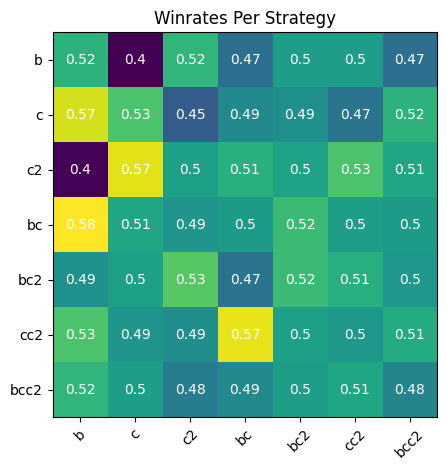

In [137]:
#All or Nothing
random.seed(67)
#1-6 Rule
s1 = 0
s2 = 0
strategies = [["best"], ["counter"], ["counter2"], ["best", "counter"], ["best", "counter2"], ["counter", "counter2"], ["best", "counter", "counter2"]]
strats = ["b", "c", "c2", "bc", "bc2", "cc2", "bcc2"]
mat = [[0 for i in range(len(strategies))] for j in range(len(strategies))]
mat_ste = [[0 for i in range(len(strategies))] for j in range(len(strategies))]
for st1 in range(len(strategies)):
    for st2 in range(len(strategies)):
        liszt = []
        for i in range(30):
            total = 0
            s1 = 0
            s2 = 0
            for j in range(30):
                strat1 = random.choice(strategies[st1])
                strat2 = random.choice(strategies[st2])
                p1, p2 = playGameAuto(strat1, strat2)
                s1 += p1
                s2 += p2
                total += p1 + p2
            liszt.append(s1/total)

        mat[st1][st2] = np.mean(liszt)
        mat_ste[st1][st2] = np.std(liszt, ddof=1)/(30**(1/2))

fig, ax = plt.subplots()
im = ax.imshow(mat)

# Show all ticks and label them with the respective list entries
ax.set_xticks(range(len(strats)), labels=strats,
              rotation=45, rotation_mode="default")
ax.set_yticks(range(len(strats)), labels=strats)

# Loop over data dimensions and create text annotations.
for i in range(len(strats)):
    for j in range(len(strats)):
        text = ax.text(j, i, round(mat[i][j], 2),
                       ha="center", va="center", color="w")
print(np.matrix(mat_ste))
ax.set_title("Player 1 Winrate Per Strategy")
ax.set_ylabel("Player 1 Strategy")
ax.set_xlabel("Player 2 Strategy")
fig.tight_layout()
plt.show()